In [1]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
class DisasterDataset(Dataset):
    def __init__(self, root_dir, limit=None):
        self.pre_dir = os.path.join(root_dir, "pre")
        self.post_dir = os.path.join(root_dir, "post")

        files = sorted(list(set(os.listdir(self.pre_dir)) & set(os.listdir(self.post_dir))))

        # 🔥 DEBUG MODE (remove later)
        if limit:
            files = files[:limit]

        self.files = files

        # ✅ FIXED INDENTATION HERE
        self.transform = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])   # 🔥 IMPORTANT
        ])

        # 🔥 CACHE EVERYTHING (MAJOR SPEED BOOST)
        self.data = []
        print("⚡ Loading dataset into RAM...")

        for f in self.files:
            pre = Image.open(os.path.join(self.pre_dir, f)).convert("L")
            post = Image.open(os.path.join(self.post_dir, f)).convert("L")

            self.data.append((
                self.transform(pre),
                self.transform(post)
            ))

        print(f"✅ Loaded {len(self.data)} samples into RAM")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [3]:
dataset = DisasterDataset(
    "I:/Dataset(new)/pix2pix_dataset/train",
     limit= None # 🔥 remove later (use full dataset)
)

loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,     # 🔥 BEST FOR WINDOWS
    pin_memory=False
)

print("Total batches:", len(loader))

⚡ Loading dataset into RAM...
✅ Loaded 11967 samples into RAM
Total batches: 1496


In [4]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = DoubleConv(1, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        b = self.bottleneck(self.pool3(e3))

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

In [5]:
model = UNet().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [6]:
from PIL import Image
import os

def clean_folder(folder):
    for file in os.listdir(folder):
        path = os.path.join(folder, file)
        try:
            with Image.open(path) as img:
                img.verify()
        except:
            print("Deleting:", path)
            try:
                os.remove(path)
            except:
                pass

clean_folder("I:/Dataset(new)/pix2pix_dataset/train/pre")
clean_folder("I:/Dataset(new)/pix2pix_dataset/train/post")

In [7]:
epochs = 15

for epoch in range(epochs):
    print(f"\n--- Epoch {epoch+1} START ---")

    model.train()
    total_loss = 0

    for i, (pre, post) in enumerate(loader):

        pre = pre.to(device)
        post = post.to(device)

        # ✅ ONLY PRE as input (no leakage)
        pred = model(pre)

        # ✅ Target = actual post image
        loss = criterion(pred, post)

        # 🚨 Skip NaN
        if torch.isnan(loss):
            print(f"⚠️ NaN at batch {i}, skipping")
            continue

        optimizer.zero_grad()
        loss.backward()

        # 🔥 Prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()

        if i % 100 == 0:
            print(f"Epoch {epoch+1} | Batch {i} | Loss {loss.item():.4f}")

    avg_loss = total_loss / len(loader)
    print(f"✅ Epoch {epoch+1} DONE | Avg Loss: {avg_loss:.4f}")


--- Epoch 1 START ---
Epoch 1 | Batch 0 | Loss 0.2677
Epoch 1 | Batch 100 | Loss 0.0551
Epoch 1 | Batch 200 | Loss 0.0523
Epoch 1 | Batch 300 | Loss 0.0955
Epoch 1 | Batch 400 | Loss 0.0361
Epoch 1 | Batch 500 | Loss 0.0478
Epoch 1 | Batch 600 | Loss 0.0807
Epoch 1 | Batch 700 | Loss 0.0656
Epoch 1 | Batch 800 | Loss 0.0292
Epoch 1 | Batch 900 | Loss 0.0475
Epoch 1 | Batch 1000 | Loss 0.0528
Epoch 1 | Batch 1100 | Loss 0.0454
Epoch 1 | Batch 1200 | Loss 0.0637
Epoch 1 | Batch 1300 | Loss 0.0768
Epoch 1 | Batch 1400 | Loss 0.0479
✅ Epoch 1 DONE | Avg Loss: 0.0529

--- Epoch 2 START ---
Epoch 2 | Batch 0 | Loss 0.0293
Epoch 2 | Batch 100 | Loss 0.0461
Epoch 2 | Batch 200 | Loss 0.0227
Epoch 2 | Batch 300 | Loss 0.0352
Epoch 2 | Batch 400 | Loss 0.0585
Epoch 2 | Batch 500 | Loss 0.0575
Epoch 2 | Batch 600 | Loss 0.0870
Epoch 2 | Batch 700 | Loss 0.0987
Epoch 2 | Batch 800 | Loss 0.0327
Epoch 2 | Batch 900 | Loss 0.0276
Epoch 2 | Batch 1000 | Loss 0.0567
Epoch 2 | Batch 1100 | Loss 0.0429

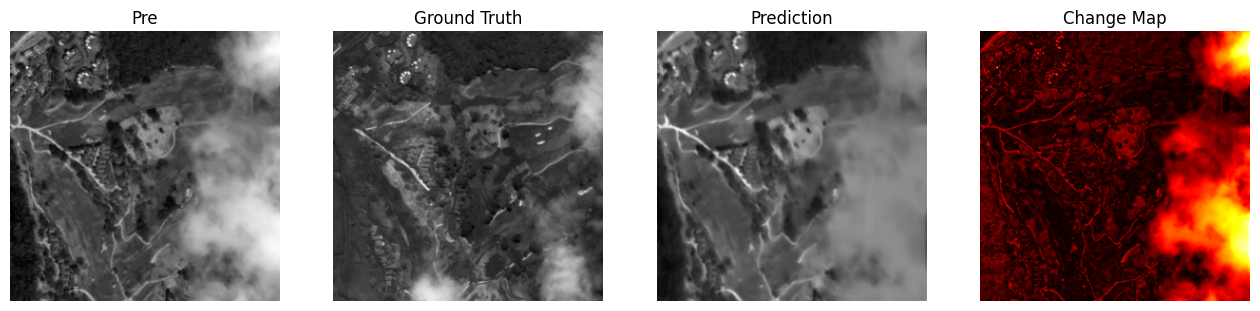

In [9]:
import matplotlib.pyplot as plt

model.eval()

# sample
pre, post = dataset[0]

pre_input = pre.unsqueeze(0).to(device)

with torch.no_grad():
    pred = model(pre_input).cpu().squeeze(0)

# denormalize
pre = pre * 0.5 + 0.5
post = post * 0.5 + 0.5
pred = pred * 0.5 + 0.5

pred = torch.clamp(pred, 0, 1)

# change map
change_map = torch.abs(pred - pre)

# plot
plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
plt.title("Pre")
plt.imshow(pre.squeeze(), cmap="gray")
plt.axis("off")

plt.subplot(1,4,2)
plt.title("Ground Truth")
plt.imshow(post.squeeze(), cmap="gray")
plt.axis("off")

plt.subplot(1,4,3)
plt.title("Prediction")
plt.imshow(pred.squeeze(), cmap="gray")
plt.axis("off")

plt.subplot(1,4,4)
plt.title("Change Map")
plt.imshow(change_map.squeeze(), cmap="hot")
plt.axis("off")

plt.show()

In [10]:
# =========================
# 💾 SAVE MODEL
# =========================

save_path = "unet_disaster_modelfinal(20).pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epochs": epochs
}, save_path)

print(f"✅ Model saved at: {save_path}")

✅ Model saved at: unet_disaster_modelfinal(20).pth
